# Calculate emissivity Lookup table with 2017 data

Following Du et al 2016, we created two LookUp Tables (LUTs) that have the K-band emissivity (H and V-pol) of non-inundated land for a given value of SM and VOD. For that, we use Windsat's TBs and collocated ERA5 skin temperature alongside LPDR's VOD and SM. This last dataset also contains an estimation of fractional water, both rolling average and non smothed version (fw and fwns). We filter the observations that are below 0.02 fw before aggragating the data.

This code shows the computation of LUTs for a local sample of data (10 days). The same code was used on a server with all data from 2017 to get the same averages and the resulting tables are displayed at the end.


In [1]:
# Common imports
import sys
sys.path.append("../")

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import xarray as xr
import os
import seaborn as sns

# from algorithm.processing.validation_data_processing import load_lpdr, load_GLWD, windsat_datacube
from algorithm.processing.validation_data_processing import select_data_variables, load_swf_validation_ds, \
    unravel_freqpol, read_config, atmospheric_corrections

xml_path = "validation_config.xml"

swf_config = read_config(xml_path)
data_paths = swf_config.get("paths")
print("LOCAL: ", swf_config.get("local"))

LOCAL:  True


In [ ]:
ds = load_swf_validation_ds(
    **data_paths
)
ds = select_data_variables(ds)

# we select only fore look
ds = ds.sel(look_direction=0)

ds = atmospheric_corrections(ds)

# Unravel pol-freq fields into single bands. dataset should be 3D (day, lat, lon)
ds = unravel_freqpol(ds, dvars=[
    "tbboa_de_lannoy"
])

# Drop the multy dimentional dvars that we dont need anymore
ds = ds.drop_vars([
    "tbtoa", "tbup", "tbdw", "tran", "tbboa_1st_order", "tbboa_de_lannoy"
])

# NOTE: for the remote dataset we should filter windsat data only covering 2017 (day_number in [0,366])
ds = ds.sel(day_number=slice(0,366))

# Get K- band emissivities with ERA5 skintemp
for freq in ["19", "37"]:
    for pol in ["H", "V"]:
        ds[f"emiss{freq}{pol}_de_lannoy"] = ds[f"tbboa_de_lannoy{freq}{pol}"] / ds["surtep_ERA5"]

# Normalize VOD between 0 and 1 using MinMax norm
min_val = 0
max_val = 3
old_attrs = ds.VOD.attrs
ds["VOD"] = (ds.VOD - min_val) /(max_val - min_val)
old_attrs.update({"Valid_range": "1-0", "Description": "NORMALIZED VOD, original is 0-3 Neper", "Units": None})
ds.VOD.attrs = old_attrs
ds

<xarray.Dataset> Size: 965MB
Dimensions:               (day_number: 11, lat: 720, lon: 1440, swath_sector: 2)
Coordinates:
  * lat                   (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                   (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * day_number            (day_number) int64 88B 1 2 3 4 5 6 7 8 9 10 196
Dimensions without coordinates: swath_sector
Data variables: (12/16)
    surtep_ERA5           (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 360, 720, 1), meta=np.ndarray>
    fwns                  (day_number, lat, lon) float32 46MB nan nan ... nan
    VOD                   (day_number, lat, lon) float32 46MB nan nan ... nan
    vsm                   (day_number, lat, lon) float32 46MB nan nan ... nan
    IGBP_landcover        (lat, lon) float32 4MB 12.0 12.0 12.0 ... 0.0 0.0 0.0
    all_classes_area_pct  (lat, lon) uint8 1MB 255 255 255 255 ... 255 255 255
    ...                    ...
    tbboa_de_lannoy37V    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    tbboa_de_lannoy37H    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss19H_de_lannoy    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss19V_de_lannoy    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss37H_de_lannoy    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss37V_de_lannoy    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

In [ ]:
# Same bins _v1 had.
example_dvar = "emiss19H_de_lannoy"
darr_shape = ds[example_dvar].shape
darr_dims = ds[example_dvar].dims

sm_bins = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5])
vod_bins = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 1])

sm_slices = [(sm_bins[i], sm_bins[i+1]) for i in range(len(sm_bins)-1)]
vod_slices = [(vod_bins[i], vod_bins[i+1]) for i in range(len(vod_bins)-1)]

# NOTE: if we do not filter swath swath dim is missing, use emiss dims instead
sm_idx = np.full(darr_shape, -1)  # initialize with -1
vod_idx = np.full(darr_shape, -1)

for i, (sm_min, sm_max) in enumerate(sm_slices):
    sm_idx[(ds.vsm >= sm_min) & (ds.vsm < sm_max)] = i  

for j, (vod_min, vod_max) in enumerate(vod_slices):
    vod_idx[(ds.VOD >= vod_min) & (ds.VOD < vod_max)] = j  

# Make sure values outside the valid range are not included, leading to extra columns and rows
valid_mask = (sm_idx >= 0) & (vod_idx >= 0)
valid_mask = xr.DataArray(valid_mask, dims=ds.dims, coords=ds.coords)

sm_idx = np.where(valid_mask, sm_idx, np.nan)
vod_idx = np.where(valid_mask, vod_idx, np.nan)

sm_idx = xr.DataArray(sm_idx, dims=darr_dims)
vod_idx = xr.DataArray(vod_idx, dims=darr_dims)

ds = ds.assign_coords(sm_bin=sm_idx, vod_bin=vod_idx)
ds

<xarray.Dataset> Size: 1GB
Dimensions:               (day_number: 11, lat: 720, lon: 1440, swath_sector: 2)
Coordinates:
  * lat                   (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                   (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * day_number            (day_number) int64 88B 1 2 3 4 5 6 7 8 9 10 196
    sm_bin                (day_number, lat, lon, swath_sector) float64 182MB ...
    vod_bin               (day_number, lat, lon, swath_sector) float64 182MB ...
Dimensions without coordinates: swath_sector
Data variables: (12/16)
    surtep_ERA5           (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 360, 720, 1), meta=np.ndarray>
    fwns                  (day_number, lat, lon) float32 46MB nan nan ... nan
    VOD                   (day_number, lat, lon) float32 46MB nan nan ... nan
    vsm                   (day_number, lat, lon) float32 46MB nan nan ... nan
    IGBP_landcover        (lat, lon) float32 4MB 12.0 12.0 12.0 ... 0.0 0.0 0.0
    all_classes_area_pct  (lat, lon) uint8 1MB 255 255 255 255 ... 255 255 255
    ...                    ...
    tbboa_1st_order37V    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    tbboa_1st_order37H    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss19H_1st_order    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss19V_1st_order    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss37H_1st_order    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss37V_1st_order    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

In [27]:
# Aggregation by index
# Fill nan with -1 to ensure type consistency
ds["sm_bin"] = ds["sm_bin"].fillna(-1).astype(int)
ds["vod_bin"] = ds["vod_bin"].fillna(-1).astype(int)

# ds = ds.compute()

# lut_array_h = ds.emiss19H_holmes.groupby(["sm_bin", "vod_bin"]).mean().values
# lut_array_v = ds.emiss19V_holmes.groupby(["sm_bin", "vod_bin"]).mean().values

# NOTE: This works fine locally but the server is having trouble with groupby
# maybe 1 year of data chunking too much for the index? 
""" 
[0;31mTypeError[0m: `group` must be an xarray.DataArray or the name of an xarray variable or dimension. Received ['sm_bin', 'vod_bin'] instead.
"""

# NOTE: I try now to create a single index instead:
smvod_idx = sm_idx * 1000 + vod_idx 
ds = ds.assign_coords(smvod=smvod_idx)
ds = ds.where(valid_mask, drop=True)
ds = ds.compute()
ds

<xarray.Dataset> Size: 1GB
Dimensions:               (day_number: 11, lat: 552, lon: 1393, swath_sector: 2)
Coordinates:
  * lat                   (lat) float32 2kB -55.38 -55.12 -54.88 ... 82.12 82.38
  * lon                   (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * day_number            (day_number) int64 88B 1 2 3 4 5 6 7 8 9 10 196
    sm_bin                (day_number, lat, lon, swath_sector) int64 135MB -1...
    vod_bin               (day_number, lat, lon, swath_sector) int64 135MB -1...
    smvod                 (day_number, lat, lon, swath_sector) float64 135MB ...
Dimensions without coordinates: swath_sector
Data variables: (12/16)
    surtep_ERA5           (day_number, lat, lon, swath_sector) float32 68MB n...
    fwns                  (day_number, lat, lon, swath_sector) float32 68MB n...
    VOD                   (day_number, lat, lon, swath_sector) float32 68MB n...
    vsm                   (day_number, lat, lon, swath_sector) float32 68MB n...
    IGBP_landcover        (lat, lon, day_number, swath_sector) float32 68MB n...
    all_classes_area_pct  (lat, lon, day_number, swath_sector) float32 68MB n...
    ...                    ...
    tbboa_1st_order37V    (day_number, lat, lon, swath_sector) float32 68MB n...
    tbboa_1st_order37H    (day_number, lat, lon, swath_sector) float32 68MB n...
    emiss19H_1st_order    (day_number, lat, lon, swath_sector) float32 68MB n...
    emiss19V_1st_order    (day_number, lat, lon, swath_sector) float32 68MB n...
    emiss37H_1st_order    (day_number, lat, lon, swath_sector) float32 68MB n...
    emiss37V_1st_order    (day_number, lat, lon, swath_sector) float32 68MB n...
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

In [30]:

# NOTE: this is super important, LUTs get the REFERENCE emissivity
reference_ds = ds[
    [dvar for dvar in ds.data_vars.keys() if dvar.startswith("emiss") or dvar == "fwns"]
]
reference_ds = reference_ds.where(reference_ds.fwns < 0.02, drop=True)
reference_ds

<xarray.Dataset> Size: 664MB
Dimensions:             (day_number: 11, lat: 524, lon: 1310, swath_sector: 2)
Coordinates:
  * lat                 (lat) float32 2kB -54.38 -54.12 -53.88 ... 82.12 82.38
  * lon                 (lon) float32 5kB -178.4 -174.6 -173.1 ... 178.9 179.1
  * day_number          (day_number) int64 88B 1 2 3 4 5 6 7 8 9 10 196
    sm_bin              (day_number, lat, lon, swath_sector) int64 121MB -1 ....
    vod_bin             (day_number, lat, lon, swath_sector) int64 121MB -1 ....
    smvod               (day_number, lat, lon, swath_sector) float64 121MB na...
Dimensions without coordinates: swath_sector
Data variables:
    fwns                (day_number, lat, lon, swath_sector) float32 60MB nan...
    emiss19H_1st_order  (day_number, lat, lon, swath_sector) float32 60MB nan...
    emiss19V_1st_order  (day_number, lat, lon, swath_sector) float32 60MB nan...
    emiss37H_1st_order  (day_number, lat, lon, swath_sector) float32 60MB nan...
    emiss37V_1st_order  (day_number, lat, lon, swath_sector) float32 60MB nan...
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

In [ ]:
# New funtion for calcluating a LUT:
def calculate_lut(ds:xr.Dataset, dvar: str, lut_name: str, only_counts=False) -> None:
    """ 
        Wrapp previous LUT calculation so that I can run on 6 dvars without going insane, thanks.
        return None. A file will be created inside the data path for LUTs
        with the given frequency name in it. <lut_{lut_name}_h.csv> etc.
        onyl_counts: compute data counts instead of mean emissivity.

    """
    data_folder = os.path.join("..","data")
    
    if only_counts:
        lut_series_counts = reference_ds[dvar].groupby("smvod").count().to_pandas()
        lut_array_counts = np.full((len(sm_slices), len(vod_slices)), np.nan)

        for sm_bin in range(len(sm_slices)):
            for vod_bin in range(len(vod_slices)):
                smvod_value = sm_bin * 1000 + vod_bin
                lut_array_counts[sm_bin, vod_bin] = lut_series_counts.get(smvod_value, np.nan)

        # DataFrame
        sm_labels = [f"{sm_min:.2f}-{sm_max:.2f}" for sm_min, sm_max in sm_slices] 
        vod_labels = [f"{vod_min:.2f}-{vod_max:.2f}" for vod_min, vod_max in vod_slices]
        df_counts = pd.DataFrame(lut_array_counts, index=sm_labels, columns=vod_labels)

        # Save
        counts_file = f"lut_counts_{lut_name}.csv"
        c_save_file = os.path.join(data_folder, counts_file)
        df_counts.to_csv(c_save_file)

        return

    lut_series = reference_ds[dvar].groupby("smvod").mean().to_pandas()
    # Reshape to original shape
    lut_array = np.full((len(sm_slices), len(vod_slices)), np.nan)

    for sm_bin in range(len(sm_slices)):
        for vod_bin in range(len(vod_slices)):
            smvod_value = sm_bin * 1000 + vod_bin
            lut_array[sm_bin, vod_bin] = lut_series.get(smvod_value, np.nan)

    # Save the LUTs into dataframes with nice labels
    # NOTE: -1 labels for nan values
    sm_labels = [f"{sm_min:.2f}-{sm_max:.2f}" for sm_min, sm_max in sm_slices] 
    vod_labels = [f"{vod_min:.2f}-{vod_max:.2f}" for vod_min, vod_max in vod_slices] 

    df = pd.DataFrame(lut_array, index=sm_labels, columns=vod_labels)

    # Save
    filename = f"lut_{lut_name}.csv"
    save_file = os.path.join(data_folder, filename)
    df.to_csv(save_file)

    return  

In [ ]:
# # Ka Band De Lannoy correction
# calculate_lut(reference_ds, dvar="emiss37H_de_lannoy", lut_name="de_lannoy_Ka_h_")
# calculate_lut(reference_ds, dvar="emiss37V_de_lannoy", lut_name="de_lannoy_Ka_v")
# calculate_lut(reference_ds, dvar="emiss37H_de_lannoy", lut_name="de_lannoy_Ka_h", only_counts=True)

# # K Band De Lannoy correction
# calculate_lut(reference_ds, dvar="emiss19H_de_lannoy", lut_name="de_lannoy_K_h")
calculate_lut(reference_ds, dvar="emiss19V_de_lannoy", lut_name="de_lannoy_K_v")
# calculate_lut(reference_ds, dvar="emiss19H_de_lannoy", lut_name="de_lannoy_K_h", only_counts=True)

## Show results from server run
We got the mean emissiivity value for all observations matching LPDR (AMSR) and Windsat for 2017, grouping by VOD and SM bins.

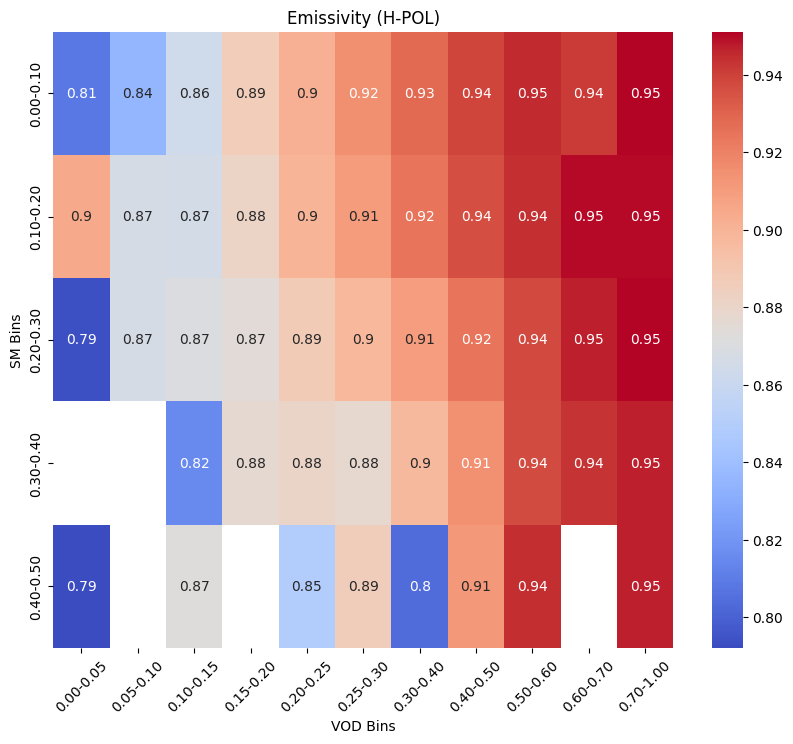

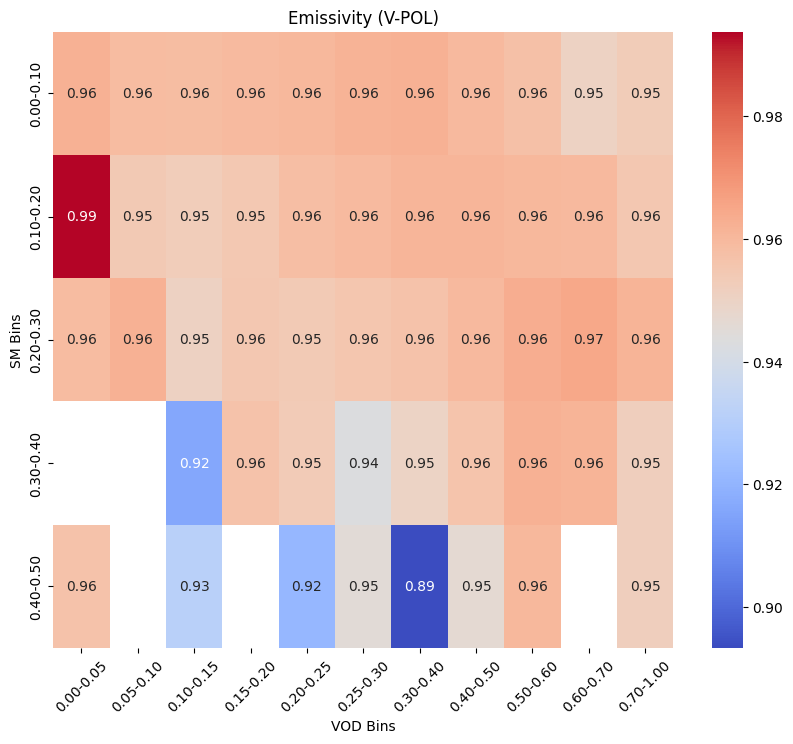

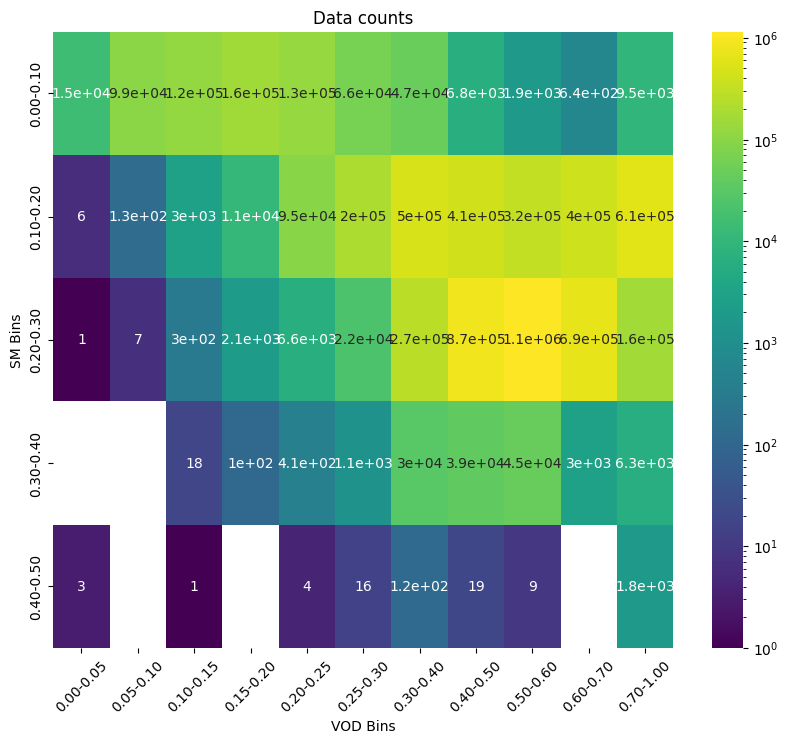

In [14]:
# Local test of remote data
if swf_config.get("local", False):
    # Same bins _v1 had.
    sm_bins = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5])
    vod_bins = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 1])

    sm_slices = [(sm_bins[i], sm_bins[i+1]) for i in range(len(sm_bins)-1)]
    vod_slices = [(vod_bins[i], vod_bins[i+1]) for i in range(len(vod_bins)-1)]

    sm_labels = [f"{sm_min:.2f}-{sm_max:.2f}" for sm_min, sm_max in sm_slices] 
    vod_labels = [f"{vod_min:.2f}-{vod_max:.2f}" for vod_min, vod_max in vod_slices] 

    # Test loading the dataset from csv
    remote_lut_h = os.path.join("..", "data","remote_data","lut_K_h.csv")
    remote_lut_v = os.path.join("..", "data","remote_data","lut_K_v.csv")
    remote_lut_counts = os.path.join("..", "data","remote_data","lut_counts.csv")

    h_df = pd.read_csv(remote_lut_h, index_col=0)
    v_df = pd.read_csv(remote_lut_v,index_col=0)
    counts_ds = pd.read_csv(remote_lut_counts, index_col=0)

    lut_array_h = h_df.values
    lut_array_v = v_df.values
    lut_array_counts = counts_ds.values

    # Display the Look-Up Table with the mean emissivity values for H-pol and V-pol
    fig, ax = plt.subplots(1,1,figsize=(10,8))
    sns.heatmap(lut_array_h, cmap='coolwarm', annot=True,ax=ax)

    ax.set_title('Emissivity (H-POL)')
    ax.set_xticklabels(vod_labels)
    ax.set_xlabel('VOD Bins')
    plt.xticks(rotation=45)
    ax.set_yticklabels(sm_labels)
    ax.set_ylabel('SM Bins')
    plt.show()

    fig, ax = plt.subplots(1,1,figsize=(10,8))
    sns.heatmap(lut_array_v, cmap='coolwarm', annot=True,ax=ax)

    ax.set_title('Emissivity (V-POL)')
    ax.set_xticklabels(vod_labels)
    ax.set_xlabel('VOD Bins')
    plt.xticks(rotation=45)
    ax.set_yticklabels(sm_labels)
    ax.set_ylabel('SM Bins')
    plt.show()

    fig, ax = plt.subplots(1,1,figsize=(10,8))
    sns.heatmap(lut_array_counts, cmap='viridis', annot=True, ax=ax, norm = LogNorm())

    ax.set_title('Data counts')
    ax.set_xticklabels(vod_labels)
    ax.set_xlabel('VOD Bins')
    plt.xticks(rotation=45)
    ax.set_yticklabels(sm_labels)
    ax.set_ylabel('SM Bins')
    plt.show()

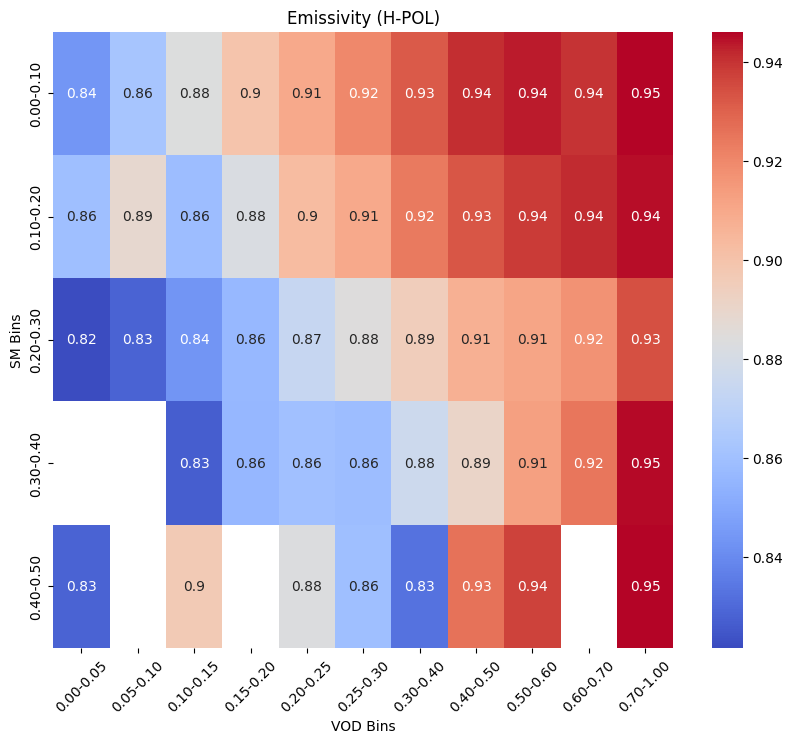

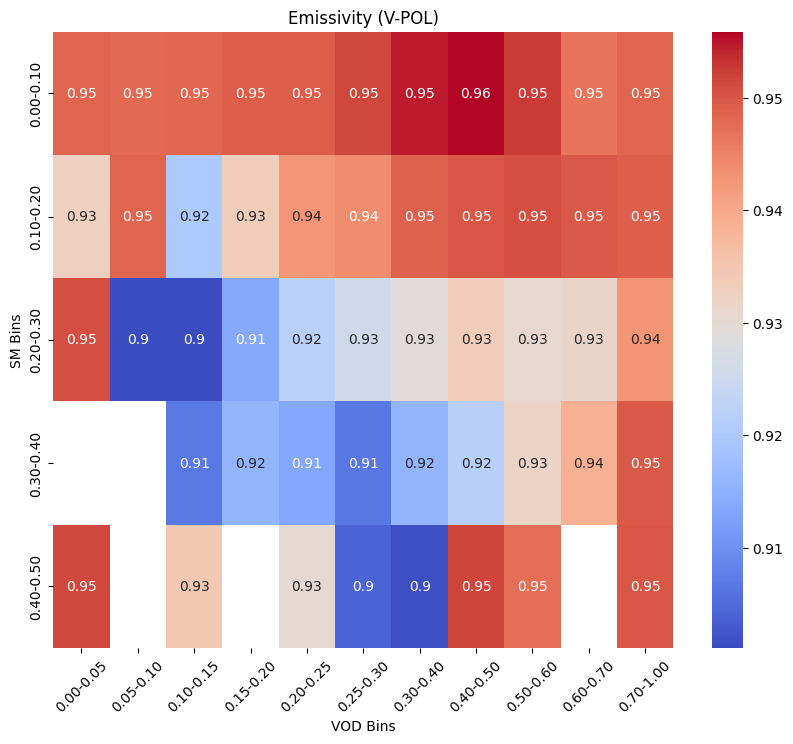

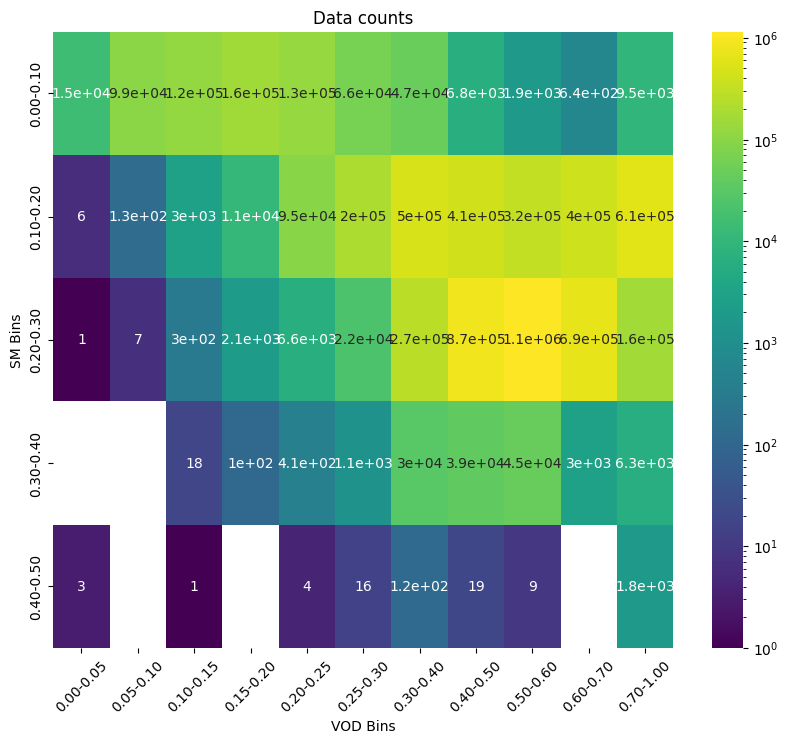

In [15]:
# Local test of remote data Ka band
if swf_config.get("local", False):
    # Same bins _v1 had.
    sm_bins = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5])
    vod_bins = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 1])

    sm_slices = [(sm_bins[i], sm_bins[i+1]) for i in range(len(sm_bins)-1)]
    vod_slices = [(vod_bins[i], vod_bins[i+1]) for i in range(len(vod_bins)-1)]

    sm_labels = [f"{sm_min:.2f}-{sm_max:.2f}" for sm_min, sm_max in sm_slices] 
    vod_labels = [f"{vod_min:.2f}-{vod_max:.2f}" for vod_min, vod_max in vod_slices] 

    # Test loading the dataset from csv
    remote_lut_h = os.path.join("..", "data","remote_data","lut_Ka_h.csv")
    remote_lut_v = os.path.join("..", "data","remote_data","lut_Ka_v.csv")
    remote_lut_counts = os.path.join("..", "data","remote_data","lut_counts_Ka.csv")

    h_df = pd.read_csv(remote_lut_h, index_col=0)
    v_df = pd.read_csv(remote_lut_v,index_col=0)
    counts_ds = pd.read_csv(remote_lut_counts, index_col=0)

    lut_array_h = h_df.values
    lut_array_v = v_df.values
    lut_array_counts = counts_ds.values

    # Display the Look-Up Table with the mean emissivity values for H-pol and V-pol
    fig, ax = plt.subplots(1,1,figsize=(10,8))
    sns.heatmap(lut_array_h, cmap='coolwarm', annot=True,ax=ax)

    ax.set_title('Emissivity (H-POL)')
    ax.set_xticklabels(vod_labels)
    ax.set_xlabel('VOD Bins')
    plt.xticks(rotation=45)
    ax.set_yticklabels(sm_labels)
    ax.set_ylabel('SM Bins')
    plt.show()

    fig, ax = plt.subplots(1,1,figsize=(10,8))
    sns.heatmap(lut_array_v, cmap='coolwarm', annot=True,ax=ax)

    ax.set_title('Emissivity (V-POL)')
    ax.set_xticklabels(vod_labels)
    ax.set_xlabel('VOD Bins')
    plt.xticks(rotation=45)
    ax.set_yticklabels(sm_labels)
    ax.set_ylabel('SM Bins')
    plt.show()

    fig, ax = plt.subplots(1,1,figsize=(10,8))
    sns.heatmap(lut_array_counts, cmap='viridis', annot=True, ax=ax, norm = LogNorm())

    ax.set_title('Data counts')
    ax.set_xticklabels(vod_labels)
    ax.set_xlabel('VOD Bins')
    plt.xticks(rotation=45)
    ax.set_yticklabels(sm_labels)
    ax.set_ylabel('SM Bins')
    plt.show()

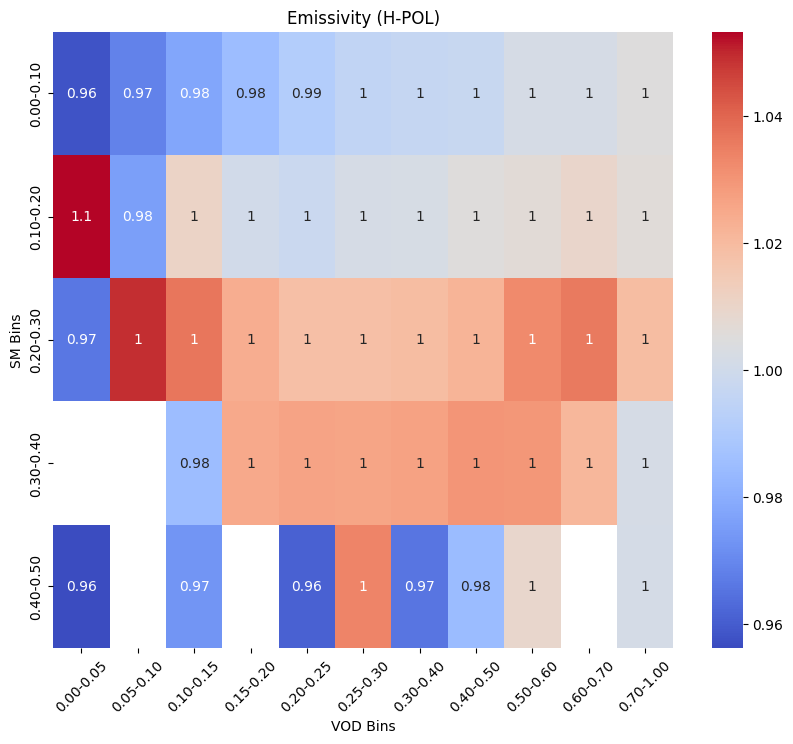

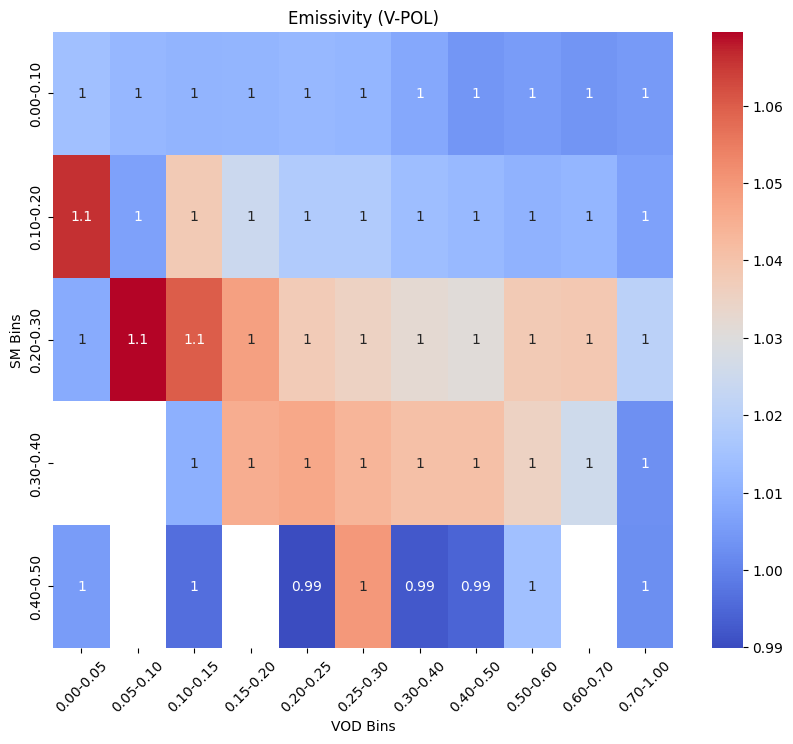

In [16]:
# Local test of remote data TB ratio
if swf_config.get("local", False):
    # Same bins _v1 had.
    sm_bins = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5])
    vod_bins = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 1])

    sm_slices = [(sm_bins[i], sm_bins[i+1]) for i in range(len(sm_bins)-1)]
    vod_slices = [(vod_bins[i], vod_bins[i+1]) for i in range(len(vod_bins)-1)]

    sm_labels = [f"{sm_min:.2f}-{sm_max:.2f}" for sm_min, sm_max in sm_slices] 
    vod_labels = [f"{vod_min:.2f}-{vod_max:.2f}" for vod_min, vod_max in vod_slices] 

    # Test loading the dataset from csv
    remote_lut_h = os.path.join("..", "data","remote_data","lut_tbratio_h.csv")
    remote_lut_v = os.path.join("..", "data","remote_data","lut_tbratio_v.csv")

    h_df = pd.read_csv(remote_lut_h, index_col=0)
    v_df = pd.read_csv(remote_lut_v,index_col=0)

    lut_array_h = h_df.values
    lut_array_v = v_df.values

    # Display the Look-Up Table with the mean emissivity values for H-pol and V-pol
    fig, ax = plt.subplots(1,1,figsize=(10,8))
    sns.heatmap(lut_array_h, cmap='coolwarm', annot=True,ax=ax)

    ax.set_title('Emissivity (H-POL)')
    ax.set_xticklabels(vod_labels)
    ax.set_xlabel('VOD Bins')
    plt.xticks(rotation=45)
    ax.set_yticklabels(sm_labels)
    ax.set_ylabel('SM Bins')
    plt.show()

    fig, ax = plt.subplots(1,1,figsize=(10,8))
    sns.heatmap(lut_array_v, cmap='coolwarm', annot=True,ax=ax)

    ax.set_title('Emissivity (V-POL)')
    ax.set_xticklabels(vod_labels)
    ax.set_xlabel('VOD Bins')
    plt.xticks(rotation=45)
    ax.set_yticklabels(sm_labels)
    ax.set_ylabel('SM Bins')
    plt.show()
